In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
s21 = pd.read_csv('data/raw/season_stats/S21.csv').sort_values(by='GAME_DATE')
p21 = pd.read_csv('data/raw/playoff_stats/P21.csv').sort_values(by='GAME_DATE')
s21 = pd.concat([s21, p21])

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])
s26.sample(10)

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF
8187,18492,2025-26,1630598,Aaron Wiggins,Aaron,1610612760,OKC,Oklahoma City Thunder,22501230,2025-12-13T00:00:00,OKC @ SAS,L,11.960000,0,4,0.000,0,4,0.000,0,0,0.000,0,1,1,0,1,0,0,0,1,0,0,-12,0.2,0,0,1.0,1,11:58,1,71.4,66.7,66.7,113.6,111.1,111.1,-42.2,-44.4,-44.4,0.000,0.00,0.0,0.000,0.063,0.032,20.0,20.0,0.000,0.000,0.167,0.177,103.55,108.36,90.30,108.36,-0.172,27,0.0,4.0,NaN,4.89,0.92,0.0,2.0,2.0,15.0,0.0,0.0,10.0,0.0,0.0,0.000,0.0,4.0,0.000,2.0,2.0,1.000,38,92,0.413,9,37,0.243,24,27,0.889,14,37,51,20,15.0,13,4,6,25,23,109,-2.0,103.9,101.9,102.7,104.7,1.2,-2.8,0.526,1.33,14.2,0.291,0.650,0.478,0.140,0.462,0.525,106.5,106.5,88.75,107,0.516,1610612759,SAS,San Antonio Spurs,37,90,0.411,13,42,0.310,24,32,0.750,15,37,52,21,19.0,9,6,4,23,25,111,2.0,102.7,104.7,103.9,101.9,-1.2,2.8,0.568,1.11,14.2,0.350,0.709,0.522,0.179,0.483,0.533,106.5,106.5,88.75,106,0.484,SG,27.0,0
149,26398,2025-26,1629027,Trae Young,Trae,1610612737,ATL,Atlanta Hawks,22500082,2025-10-22T00:00:00,ATL vs. TOR,L,34.300000,5,14,0.357,1,7,0.143,11,13,0.846,0,1,1,5,2,1,0,0,4,11,22,-14,31.7,0,0,31.0,1,34:18,1,112.2,110.5,110.5,124.9,129.8,129.8,-12.7,-19.3,-19.3,0.208,2.50,18.5,0.000,0.030,0.013,7.4,7.5,0.393,0.558,0.232,0.240,120.27,118.95,99.13,118.95,0.066,86,5.0,14.0,G,4.47,2.46,0.0,3.0,3.0,63.0,1.0,2.0,36.0,2.0,5.0,0.400,3.0,9.0,0.333,4.0,4.0,1.000,38,90,0.422,10,35,0.286,32,37,0.865,8,26,34,25,16.0,7,6,4,24,31,118,-20.0,103.3,104.4,120.3,122.1,-17.0,-17.7,0.658,1.56,16.7,0.214,0.667,0.416,0.142,0.478,0.555,114.5,113.0,94.17,113,0.384,1610612761,TOR,Toronto Raptors,54,95,0.568,6,25,0.240,24,29,0.828,12,42,54,36,19.0,10,4,6,31,24,138,20.0,120.3,122.1,103.3,104.4,17.0,17.7,0.667,1.89,22.0,0.333,0.786,0.584,0.168,0.600,0.640,114.5,113.0,94.17,113,0.616,PG,27.0,0
10051,16474,2025-26,1641710,Anthony Black,Anthony,1610612753,ORL,Orlando Magic,22500433,2025-12-27T00:00:00,ORL vs. DEN,W,30.100000,14,24,0.583,7,11,0.636,3,6,0.500,3,3,6,5,1,2,0,2,4,3,38,6,57.7,0,0,60.0,1,30:06,1,134.2,137.1,137.1,126.9,123.4,123.4,7.2,13.7,13.7,0.278,5.00,15.6,0.097,0.107,0.102,3.1,3.1,0.729,0.713,0.375,0.382,100.15,100.47,83.72,100.47,0.207,62,14.0,24.0,G,4.40,2.35,5.0,3.0,8.0,52.0,0.0,1.0,25.0,5.0,9.0,0.556,9.0,15.0,0.600,1.0,2.0,0.500,46,89,0.517,10,29,0.345,25,37,0.676,9,26,35,32,6.0,8,0,3,2

In [203]:
res = []
for df in [s21, s22, s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)
    df['GAME_POINT_DIFF'] = df['TEAM_PTS'] - df['OPP_PTS']
    df['IS_BLOWOUT'] = (df['GAME_POINT_DIFF'].abs() > 15).astype(int)

    df = min_features(df)

    df['TEAM_RATING_SMOOTH'] = df.groupby('TEAM_ID')['TEAM_NET_RATING'].transform(
        lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
    df['OPP_RATING_SMOOTH'] = df.groupby('OPP_TEAM_ID')['OPP_NET_RATING'].transform(
        lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
    df['EXPECTED_SPREAD'] = np.where(
        df['IS_HOME'] == 1,
        ((df['TEAM_RATING_SMOOTH'] - df['OPP_RATING_SMOOTH']) * -1.0) - 3.0,
        ((df['TEAM_RATING_SMOOTH'] - df['OPP_RATING_SMOOTH']) * -1.0) + 3.0)
    df['EXPECTED_SPREAD'] = df['EXPECTED_SPREAD'].clip(lower=-20, upper=20)
    df['BLOWOUT_RISK'] = (df['EXPECTED_SPREAD'].abs() >= 10).astype(int)

    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))

    # Calculate the player's personal season-to-date baseline
    player_stats = df.groupby('PLAYER_ID')['MIN']
    # Use expanding() to avoid look-ahead bias (only uses games played UP TO that date)
    df['MIN_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['MIN_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    # The Z-score of their current 10-game average relative to their own season
    df['MIN_ROLE_Z_SCORE'] = (df['MIN_roll10'] - df['MIN_SEASON_MEAN']) / df['MIN_SEASON_STD']
    df['MIN_VOLATILITY_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(
    lambda x: x.rolling(window=10, min_periods=1).std().shift(1))
    df['MIN_VOLATILITY_RELATIVE'] = df['MIN_VOLATILITY_L10'] / df['MIN_roll10']
    df['MIN_TREND'] = df['MIN_5_ewm'] - df['MIN_10_ewm']
        
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df['ROLE_LOCK'] = (
        df['STARTER_ROLL10_PCT'] *                         
        np.exp(-df['MIN_std10'] / df['MIN_10_ewm']))
    df['ROLE_SHOCK'] = (df['MIN_5_ewm'] - df['MIN_SEASON_MEAN']) / df['MIN_SEASON_MEAN']                            

    df['MIN_MIN_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['MIN_MAX_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())
    # Does this player's rank on the team make them a "Garbage Time" candidate?
    df['LOW_RANK_BLOWOUT'] = (df['TEAM_MIN_RANK_L10'] > 5).astype(int) * df['EXPECTED_SPREAD'].abs()
    # How much is the player playing relative to their season norm?
    df['MIN_SEASON_RATIO'] = df['MIN_10_ewm'] / (df['MIN_SEASON_MEAN'] + 1e-6)
    # The 'Vulnerability' Score
    # High score = A player who is NOT a top star, playing in a high-spread game.
    df['BLOWOUT_VULNERABILITY'] = df['TEAM_MIN_RANK_L10'] * df['EXPECTED_SPREAD'].abs()
    # Coefficient of Variation (CV)
    # High CV = the '0 or 30' player. Low CV = the 'Consistent 15' player.
    df['MIN_CV_L10'] = df['MIN_std10'] / (df['MIN_roll10'] + 1e-6)
    df['SPREAD_ZONE'] = np.where(df['EXPECTED_SPREAD'].abs() > 12.5, 1, 0)
    df['STARTER_IN_DANGER'] = df['STARTING'] * df['SPREAD_ZONE']
    df['DIST_PER_MIN'] = df['DIST_10_ewm'] / (df['MIN_10_ewm'] + 1e-6)

    # df['MIN_REG'] = df['MIN'].clip(upper=48)
    # df = df[(df['MIN_REG'] >= 15) | (df['STARTING'] == 1)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.sample(10)

(163869, 332)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF,STARTING,GAME_POINT_DIFF,IS_BLOWOUT,MIN_roll3,PTS_roll3,PLUS_MINUS_roll3,PF_roll3,POSS_roll3,PIE_roll3,USG_PCT_roll3,TS_PCT_roll3,NET_RATING_roll3,MIN_roll5,PTS_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,MIN_roll10,PTS_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,MIN_3_ewm,PTS_3_ewm,PLUS_MINUS_3_ewm,PF_3_ewm,POSS_3_ewm,PIE_3_ewm,USG_PCT_3_ewm,TS_PCT_3_ewm,NET_RATING_3_ewm,DIST_3_ewm,SPD_3_ewm,TCHS_3_ewm,MIN_5_ewm,PTS_5_ewm,PLUS_MINUS_5_ewm,PF_5_ewm,POSS_5_ewm,PIE_5_ewm,USG_PCT_5_ewm,TS_PCT_5_ewm,NET_RATING_5_ewm,DIST_5_ewm,SPD_5_ewm,TCHS_5_ewm,MIN_10_ewm,PTS_10_ewm,PLUS_MINUS_10_ewm,PF_10_ewm,POSS_10_ewm,PIE_10_ewm,USG_PCT_10_ewm,TS_PCT_10_ewm,NET_RATING_10_ewm,DIST_10_ewm,SPD_10_ewm,TCHS_10_ewm,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_ewm_season_avg,PTS_ewm_season_avg,PLUS_MINUS_ewm_season_avg,PF_ewm_season_avg,POSS_ewm_season_avg,PIE_ewm_season_avg,USG_PCT_ewm_season_avg,TS_PCT_ewm_season_avg,NET_RATING_ewm_season_avg,STAR_PLAYER_ID,STAR_OUT_FLAG,STAR_POS,STAR_SAME_POS,STAR_SAME_POS_GROUP,MIN_WHEN_STAR_IN,MIN_WHEN_STAR_OUT,MIN_STAR_OUT_DELTA,TEAM_PACE_roll10,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,ROLE_TIER,ROLE_TIER_BENCH,ROLE_TIER_ROLE,ROLE_TIER_STAR,ROLE_TIER_BENCH_x_USG,ROLE_TIER_BENCH_x_PACE,ROLE_TIER_ROLE_x_USG,ROLE_TIER_ROLE_x_PACE,ROLE_TIER_STAR_x_USG,ROLE_TIER_STAR_x_PACE,TEAM_RATING_SMOOTH,OPP_RATING_SMOOTH,EXPECTED_SPREAD,BLOWOUT_RISK,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,MIN_SEASON_MEAN,MIN_SEASON_STD,MIN_ROLE_Z_SCORE,MIN_VOLATILITY_L10,MIN_VOLATILITY_RELATIVE,MIN_TREND,GP,ROLE_LOCK,ROLE_SHOCK,MIN_MIN_L10,MIN_MAX_L10,LOW_RANK_BLOWOUT,MIN_SEASON_RATIO,BLOWOUT_VULNERABILITY,MIN_CV_L10,SPREAD_ZONE,STARTER_IN_DANGER,DIST_PER_MIN
159195,2025-26,1642273,Kyshawn George,Kyshawn,1610612764,

In [204]:
df.to_csv('data/processed/training/S26_TRAINING_MIN.csv', index=False)

# Layer 1 — MIN model prediction (your base)
base_mins = min_model.predict(X)

# Layer 2 — contextual multipliers
def adjust_minutes(base_mins, context):
    mins = base_mins
    
    # Pace adjustment
    pace_factor = context['opp_pace_l10'] / league_avg_pace
    mins *= (0.85 + 0.15 * pace_factor)  # dampen, don't scale 1:1
    
    # Star out — usage redistribution
    if context['star_out']:
        mins *= 1.06  # role players absorb ~6% more mins
    
    # Blowout risk (you should add this even if rest/home didnt work)
    if abs(context['spread']) > 12:
        mins *= 0.88
        
    return np.clip(mins, 10, 42)  # hard bounds, no model should predict 0 or 48

In [185]:
MIN_FEATURES = [
    'STARTING',
    'MIN_10_ewm',
    'TEAM_MIN_RANK_L10',
    'STARTER_ROLL10_PCT',
    'MIN_SEASON_MEAN',
    'MIN_lag1',
    'MIN_SEASON_STD',
    'MIN_MAX_L10',
    'IS_PLAYOFF',
]

### NaN Percentage by feature

In [186]:
na_rate = df[MIN_FEATURES].isna().mean().sort_values(ascending=False)
na_rate.head(20)

MIN_MAX_L10           0.158435
TEAM_MIN_RANK_L10     0.044843
STARTER_ROLL10_PCT    0.044843
MIN_SEASON_STD        0.029099
MIN_10_ewm            0.013808
MIN_SEASON_MEAN       0.013808
MIN_lag1              0.013808
STARTING              0.000000
IS_PLAYOFF            0.000000
dtype: float64

In [191]:
from sklearn.model_selection import TimeSeriesSplit

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[MIN_FEATURES + ["MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[MIN_FEATURES]
y = ppm_df["MIN"]

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1828,
    max_depth          = 5,
    learning_rate      = 0.019058023170429123,
    subsample          = 0.6604528698837521,
    colsample_bytree   = 0.6710615957337823,
    reg_alpha          = 0.004619045167128926,
    reg_lambda         = 0.06143534302677916,
    min_child_weight   = 3,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Training data size: {len(X)}")

tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Training data size: 123407
TSCV fold 1                    | MAE: 4.046 | R²: 0.502 | 80% Coverage: 77.8%
TSCV fold 2                    | MAE: 3.988 | R²: 0.504 | 80% Coverage: 79.0%
TSCV fold 3                    | MAE: 4.005 | R²: 0.521 | 80% Coverage: 78.2%
TSCV fold 4                    | MAE: 3.972 | R²: 0.497 | 80% Coverage: 80.0%
TSCV fold 5                    | MAE: 3.923 | R²: 0.449 | 80% Coverage: 80.4%

TimeSeriesSplit Summary
  MAE      : 3.987 ± 0.041
  R²       : 0.495  ± 0.024
  Coverage : 79.1% ± 1.0%  (target ~80%)


In [190]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=4)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Phase 2: Walk-Forward Validation

In [192]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")

WF fold 1 (2023-10-30 00:00:00 → 2024-02-22 00:00:00) | MAE: 3.962 | R²: 0.503 | 80% Coverage: 78.4%
WF fold 2 (2024-02-22 00:00:00 → 2024-12-01 00:00:00) | MAE: 4.008 | R²: 0.535 | 80% Coverage: 78.6%
WF fold 3 (2024-12-01 00:00:00 → 2025-03-23 00:00:00) | MAE: 3.863 | R²: 0.511 | 80% Coverage: 80.8%
WF fold 4 (2025-03-23 00:00:00 → 2026-01-02 00:00:00) | MAE: 4.039 | R²: 0.465 | 80% Coverage: 80.1%

Walk-Forward Summary
  MAE      : 3.968 ± 0.067
  R²       : 0.504  ± 0.025
  Coverage : 79.5% ± 1.0%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2023-10-30 00:00:00 → 2024-02-22 00:00:00) 3.962  ███████████████
  WF fold 2 (2024-02-22 00:00:00 → 2024-12-01 00:00:00) 4.008  ████████████████
  WF fold 3 (2024-12-01 00:00:00 → 2025-03-23 00:00:00) 3.863  ███████████████
  WF fold 4 (2025-03-23 00:00:00 → 2026-01-02 00:00:00) 4.039  ████████████████


### Residual Visuals

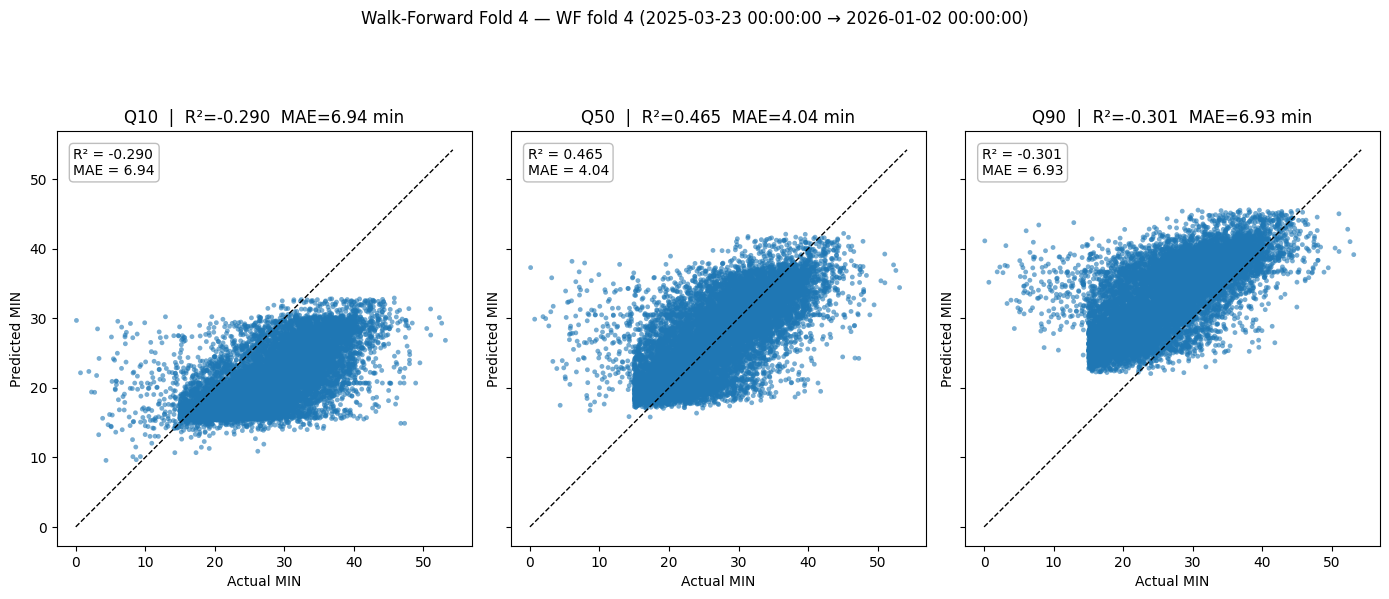

Per-quantile fit on last validation fold:
  Q10: R²=-0.290  MAE=6.941 min
  Q50: R²=+0.465  MAE=4.039 min
  Q90: R²=-0.301  MAE=6.928 min
Coverage per quantile (should match quantile value):
  Q10: 10.6%  (target 10%, delta +0.6%)
  Q50: 51.8%  (target 50%, delta +1.8%)
  Q90: 90.7%  (target 90%, delta +0.7%)

80% interval width (Q10→Q90):
  mean : 12.77 min
  median: 12.56 min
  std  : 2.22 min


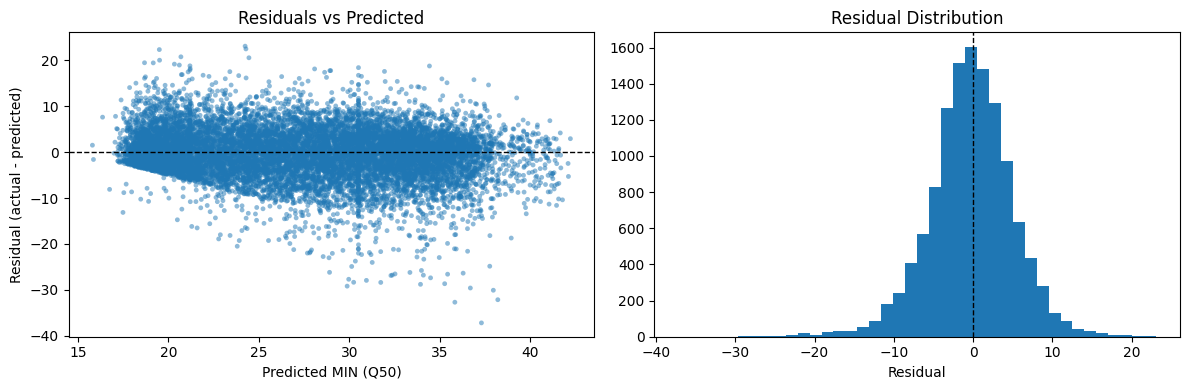


Residual summary:
  mean bias : -0.347 min  (close to 0 = unbiased)
  std       : 5.389 min


In [193]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter (with R^2 and MAE per quantile) ──────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
metrics = {}
for ax, (name, y_pred) in zip(axes, preds.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")

    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

In [194]:
ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE", "PLAYER_NAME"]].sort_values("GAME_DATE").reset_index(drop=True)

val_df = ppm_df.iloc[train_end:val_end].reset_index(drop=True)

player_col = "PLAYER_NAME" if "PLAYER_NAME" in val_df.columns else None
if player_col is None:
    raise ValueError("Add PLAYER_NAME to ppm_df columns (see comment above).")

pred50 = np.asarray(pred_mid).reshape(-1)
pred10 = np.asarray(pred_low).reshape(-1)
pred90 = np.asarray(pred_high).reshape(-1)

out = pd.DataFrame({
    "player": val_df[player_col].values,
    "actual_min": np.asarray(y_true).reshape(-1),
    "pred_min_q50": pred50,
    "interval_width": pred90 - pred10
})
out["error"] = out["actual_min"] - out["pred_min_q50"]
out["abs_error"] = out["error"].abs()

# optional: tie-break sort
if "GAME_DATE" in val_df.columns:
    out["game_date"] = val_df["GAME_DATE"].values

print(out.sort_values("interval_width", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.3f} | RMSE: {np.sqrt((out['error']**2).mean()):.3f}")

            player  actual_min  pred_min_q50  interval_width     error  abs_error  game_date
         Dru Smith   17.666667     17.937452        6.546152 -0.270786   0.270786 2025-12-03
         Dru Smith   16.078333     18.016413        6.572107 -1.938079   1.938079 2025-12-01
        Jaden Ivey   28.733333     17.383072        6.690480 11.350261  11.350261 2025-12-28
        Kevin Love   16.516667     17.191267        6.778584 -0.674600   0.674600 2025-12-05
      Caris LeVert   22.500000     18.319622        6.800560  4.180378   4.180378 2025-11-24
        Kevin Love   20.386667     17.292395        6.819610  3.094272   3.094272 2025-12-12
         Dru Smith   16.683333     17.627403        6.820082 -0.944070   0.944070 2025-11-05
       Gary Harris   22.186667     17.185385        6.834050  5.001282   5.001282 2025-04-25
 Marvin Bagley III   16.750000     16.994329        6.841630 -0.244329   0.244329 2025-11-16
        Josh Green   19.511667     17.417370        6.848619  2.094297

In [195]:
# 1. Check if predictions are collapsing to a narrow band
print(out['pred_min_q50'].describe())
# If std is <3, you have mean collapse

# 2. Check error by predicted value bucket
out['pred_bucket'] = pd.cut(out['pred_min_q50'], bins=[20,25,35,48])
out.groupby('pred_bucket')['error'].agg(['mean','std','count'])

count    12340.000000
mean        27.574970
std          5.874323
min         15.799307
25%         22.166667
50%         27.819138
75%         32.506137
max         42.204433
Name: pred_min_q50, dtype: float64


,mean,std,count
pred_bucket,,,
"(20, 25]",0.368420,5.104929,2919
"(25, 35]",-0.808451,5.671485,6382
"(35, 48]",-1.312584,5.510463,1393



── q_0.10 ──


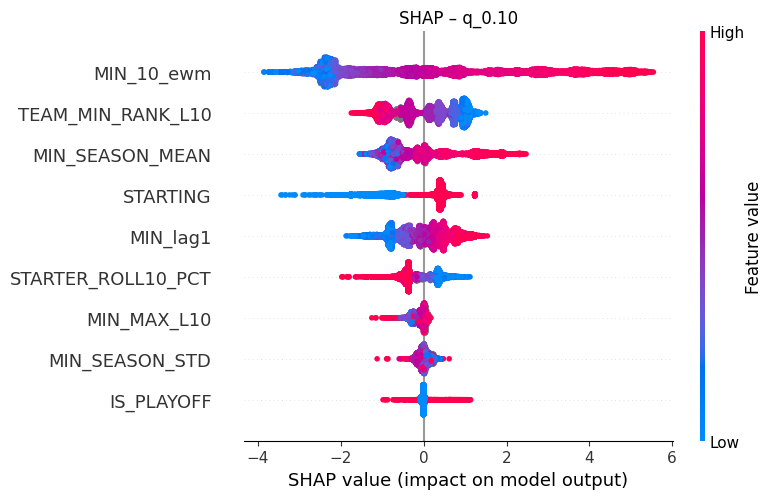


── q_0.50 ──


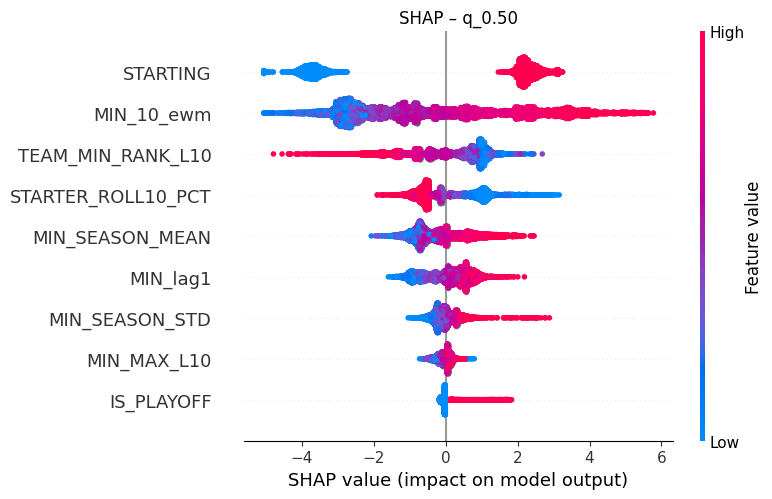


── q_0.90 ──


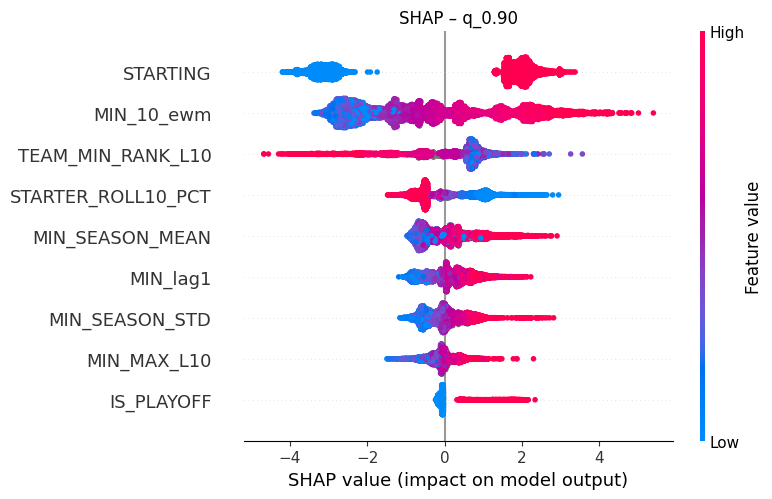

In [196]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

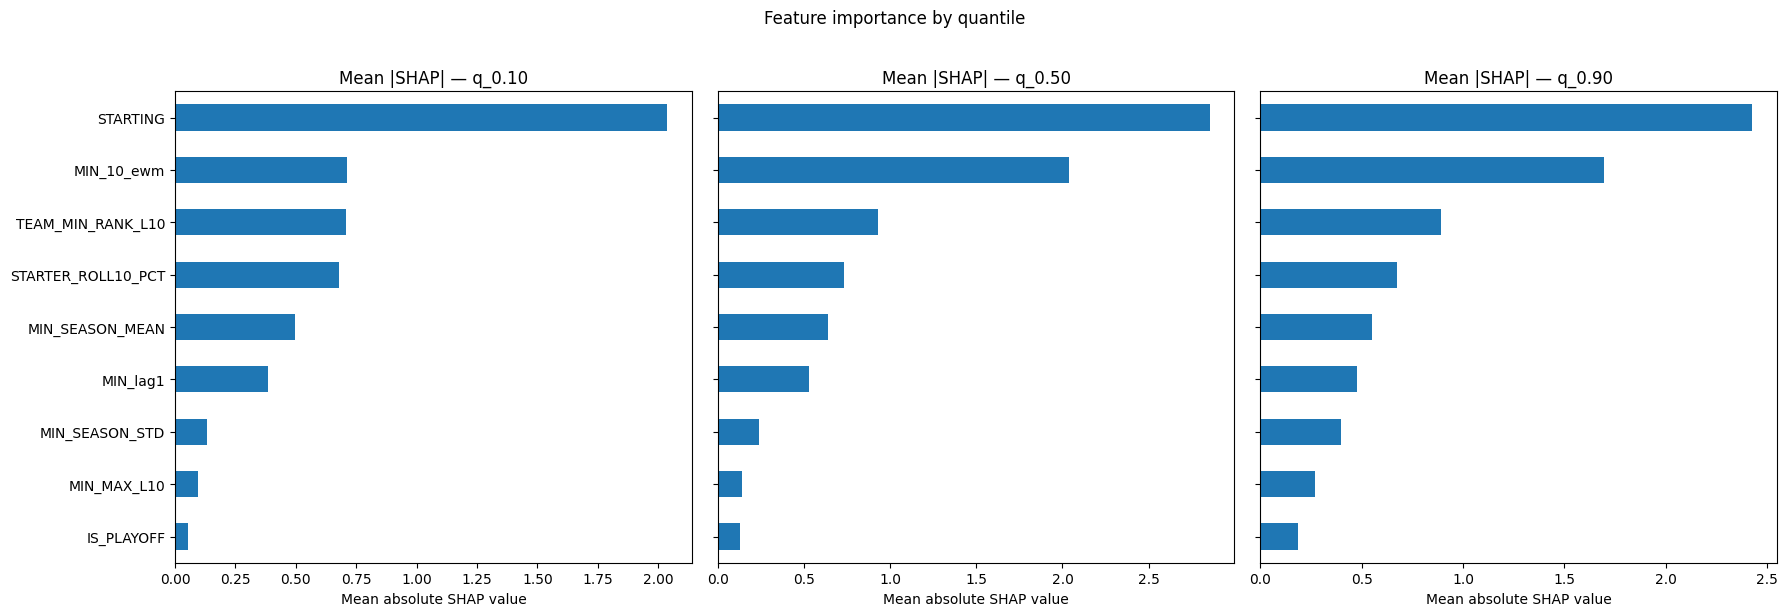

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (q_key, model) in zip(axes, models_last.items()):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feat_imp      = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=ax)
    ax.set_title(f"Mean |SHAP| — {q_key}")
    ax.set_xlabel("Mean absolute SHAP value")

plt.suptitle("Feature importance by quantile", y=1.02)
plt.tight_layout()
plt.show()

In [198]:
explainer_low  = shap.TreeExplainer(models_last["q_0.10"])
explainer_high = shap.TreeExplainer(models_last["q_0.90"])

shap_low  = explainer_low(X_val_last).values
shap_high = explainer_high(X_val_last).values

divergence = pd.Series(
    np.abs(shap_high - shap_low).mean(axis=0),
    index=MIN_FEATURES
).sort_values(ascending=False)

print("\nFeatures driving Q10 vs Q90 spread (uncertainty drivers):")
print(divergence.head(10).to_string())


Features driving Q10 vs Q90 spread (uncertainty drivers):
STARTING              1.752863
MIN_10_ewm            0.714686
TEAM_MIN_RANK_L10     0.481165
MIN_SEASON_STD        0.453610
STARTER_ROLL10_PCT    0.319401
MIN_SEASON_MEAN       0.282039
MIN_MAX_L10           0.212762
MIN_lag1              0.186720
IS_PLAYOFF            0.147081


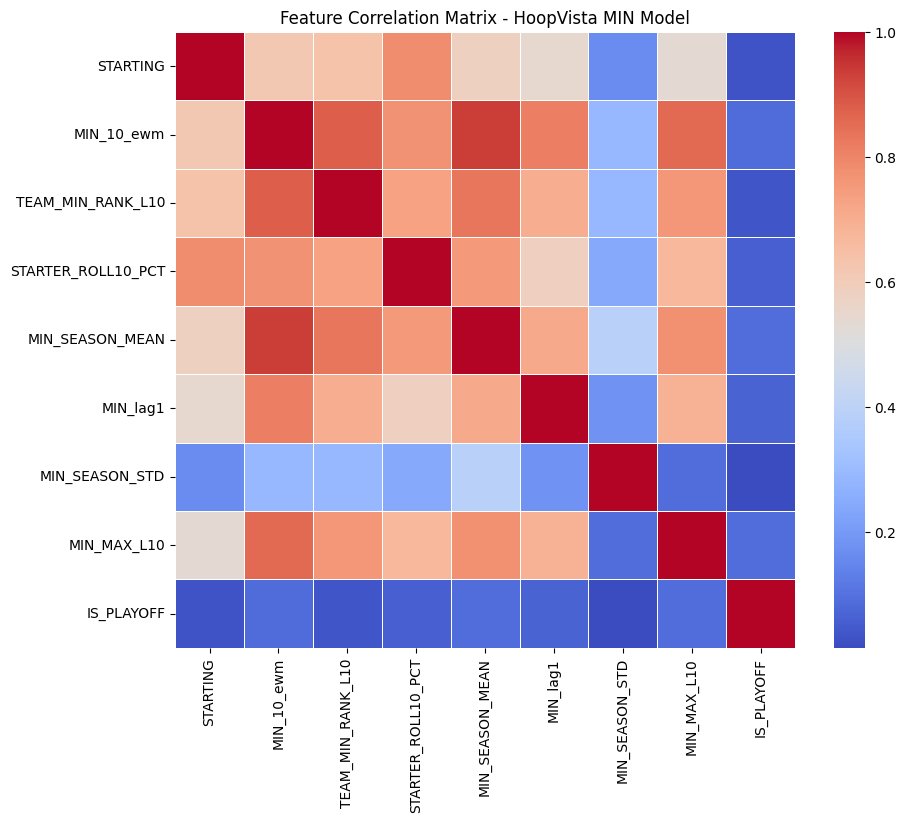

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [199]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [201]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"min_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to min_quantile_xgb_2026-01-02.joblib
Loaded model MAE: 4.039
Trained on data up to: 2025-03-23 00:00:00
Validated on data up to: 2026-01-02 00:00:00
